## Data preparation and exploration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel("../data/data.xlsx")

In [3]:
# df.shape
# df.info()
# df.isna().sum()
# df.duplicated().sum()
# df[["Quantity", "UnitPrice"]].describe()
# print(df["InvoiceNo"].astype(str).str.startswith("C").sum())
# print((df["Quantity"] <= 0).sum())
# print((df["UnitPrice"] <= 0).sum())
print(df["InvoiceDate"].min())
print(df["InvoiceDate"].max())
print(df["CustomerID"].nunique())
print(df["InvoiceNo"].nunique())
print(df["StockCode"].nunique())
print(df["Country"].value_counts().head(10))

2010-12-01 08:26:00
2011-12-09 12:50:00
4372
25900
4070
Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64


## Data Cleaning:

In [4]:
df = df.drop_duplicates()
print(df.shape)
indexes = df[df["Quantity"] <= 0].index
df = df.drop(index=indexes)
print(df.shape)
df = df.dropna(subset=["CustomerID"])
print(df.shape)
ind = df[df["InvoiceNo"].astype(str).str.startswith("C")].index
df = df.drop(index=ind)
print(df.shape)
ind = df[df["UnitPrice"] <= 0].index
df = df.drop(index=ind)
print(df.shape)
df["CustomerID"] = df["CustomerID"].astype(int)
df["CustomerID"].dtype

mask = df["StockCode"].astype(str).str[:5].str.isdigit()
df[~mask]["StockCode"].value_counts()
df = df[mask]
print(df.shape)

(536641, 8)
(526054, 8)
(392732, 8)
(392732, 8)
(392692, 8)
(391150, 8)


## RFM

In [5]:
from datetime import datetime
df["Amount"] = df["UnitPrice"] * df["Quantity"]

df["InvoiceDate"].max()
reference_date = datetime(2011, 12, 10)
reference_date
# reference_date - df["InvoiceDate"].max()
rfm = df.groupby("CustomerID").agg(
    Recency = ("InvoiceDate", "max"),
    Frequency = ("InvoiceNo", "nunique"),
    Monetary = ("Amount", "sum"),
)
rfm["Recency"] = (reference_date - rfm["Recency"]).dt.days
rfm = rfm.reset_index()
rfm

,CustomerID,Recency,Frequency,Monetary
0,12346,325,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1437.24
3,12349,18,1,1457.55
4,12350,310,1,294.40
...,...,...,...,...
4329,18280,277,1,180.60
4330,18281,180,1,80.82
4331,18282,7,2,178.05
4332,18283,3,16,2039.58


## Cluestring Preparation:

np.float64(1.2426864615841866)

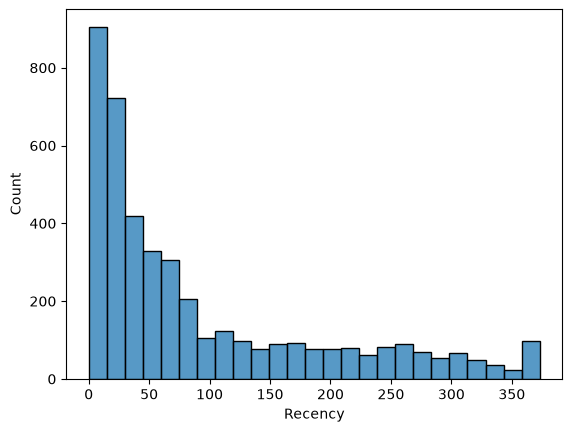

In [6]:
sns.histplot(rfm, x="Recency")
# most costumers baught are recent 
# skew > 0 which means its right-skewed
rfm["Recency"].skew()


np.float64(11.949414516742257)

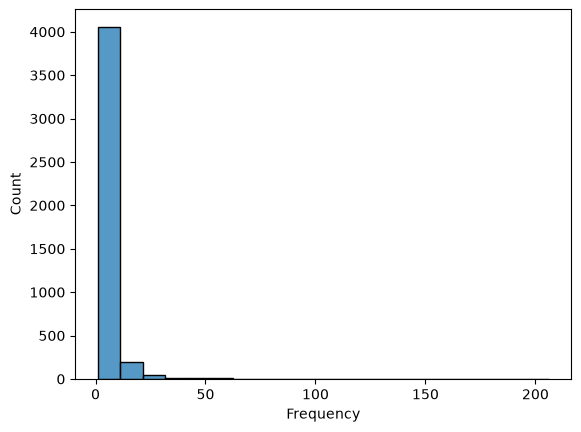

In [7]:
sns.histplot(rfm, x="Frequency", bins=20)
# skew > 0 which means its right-skewed
rfm["Frequency"].skew()


np.float64(19.578006249138994)

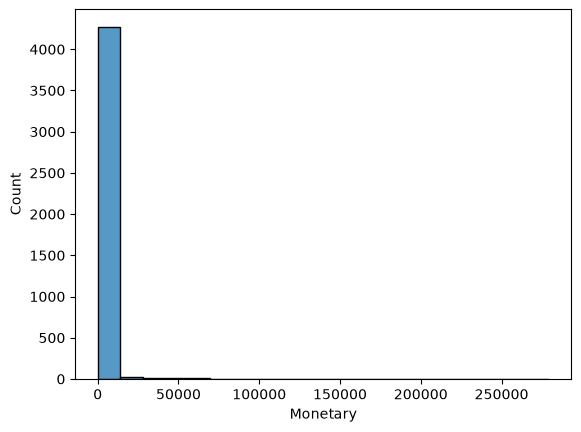

In [8]:
sns.histplot(rfm, x="Monetary", bins=20)
# skew > 0 which means its right-skewed
rfm["Monetary"].skew()


## Log Transformation:

Recency       1.242686
Frequency    11.949415
Monetary     19.578006
dtype: float64


Recency     -0.466852
Frequency    1.213867
Monetary     0.398802
dtype: float64

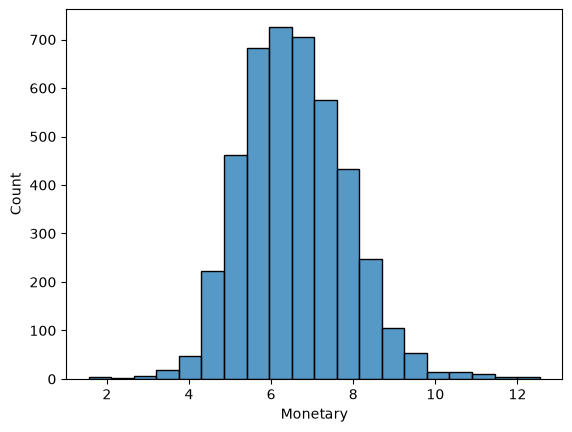

In [9]:
rfm_log = np.log1p(rfm[["Recency", "Frequency", "Monetary"]])
sns.histplot(rfm_log, x="Monetary", bins=20)
print(rfm[["Recency", "Frequency", "Monetary"]].skew())
rfm_log[["Recency", "Frequency", "Monetary"]].skew()


## Standarization:

In [10]:
from sklearn.preprocessing import StandardScaler

rfm_standarized = StandardScaler().fit_transform(rfm_log)

rfm_standarized = pd.DataFrame(rfm_standarized, columns=["Recency", "Frequency", "Monetary"])
print(rfm_standarized.mean())
print(rfm_standarized.std())

print(rfm_log.mean())
print(rfm_log.std())



Recency      7.025094e-16
Frequency   -3.852735e-17
Monetary     5.049542e-16
dtype: float64
Recency      1.000115
Frequency    1.000115
Monetary     1.000115
dtype: float64
Recency      3.802431
Frequency    1.341639
Monetary     6.575495
dtype: float64
Recency      1.384076
Frequency    0.681783
Monetary     1.255017
dtype: float64


## Segmentation with K-Means:

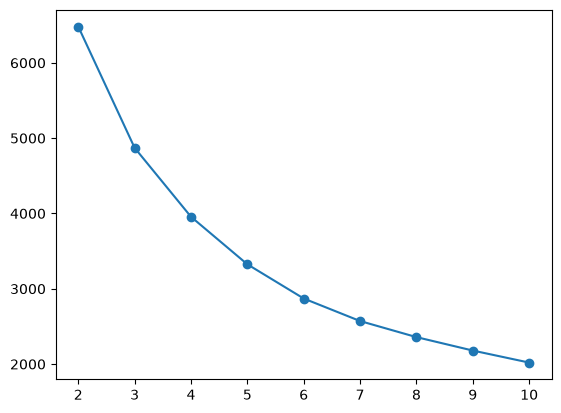

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_inertia = []
silhouette_scores = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, init="k-means++", random_state=77, n_init=10)
    km.fit(rfm_standarized)
    k_inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(rfm_standarized, km.labels_))

plt.plot(list(range(2, 11)), k_inertia, marker="o")
plt.show()

## Applying K-Means with K = 3

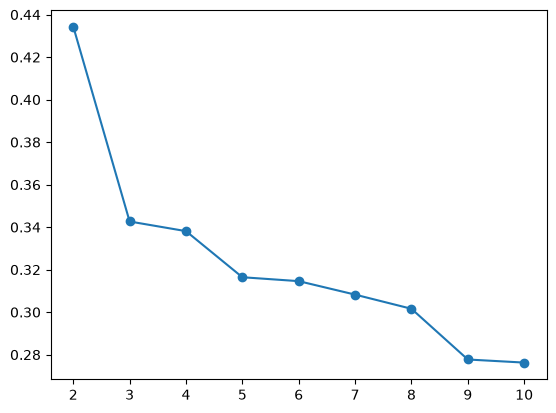

In [12]:
plt.plot(list(range(2, 11)), silhouette_scores, marker="o")
plt.show()

In [13]:
km = KMeans(n_clusters=3, init="k-means++", random_state=77, n_init=10)
labels = km.fit_predict(rfm_standarized)
rfm["Cluster"] = labels
rfm
rfm["Cluster"].value_counts()
rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,13.431457,14.001443,8183.354892
1,160.847173,1.351503,360.098370
2,44.492849,3.603099,1406.012872


## Profiling

In [14]:
profile = rfm.groupby("Cluster").agg(
    Customers = ("Recency", "size"),
    Recency = ("Recency", "mean"),
    Frequency = ("Frequency", "mean"),
    Monetary = ("Monetary", "mean"),
    Monetary_total = ("Monetary", "sum"),
)
profile

,Customers,Recency,Frequency,Monetary,Monetary_total
Cluster,,,,,
0,693,13.431457,14.001443,8183.354892,5671064.94
1,1963,160.847173,1.351503,360.098370,706873.10
2,1678,44.492849,3.603099,1406.012872,2359289.60


In [15]:
profile["Monetary_total%"] = (profile["Monetary_total"] / profile["Monetary_total"].sum() * 100).round(1)
profile["Customers_%"] = (profile["Customers"] / profile["Customers"].sum() * 100).round(1)
profile.reset_index()

,Cluster,Customers,Recency,Frequency,Monetary,Monetary_total,Monetary_total%,Customers_%
0,0,693,13.431457,14.001443,8183.354892,5671064.94,64.9,16.0
1,1,1963,160.847173,1.351503,360.098370,706873.10,8.1,45.3
2,2,1678,44.492849,3.603099,1406.012872,2359289.60,27.0,38.7


In [16]:
names = {0: "VIP", 1: "Inactive", 2: "Regular"}
rfm["Class"] = rfm["Cluster"].map(names)
rfm

,CustomerID,Recency,Frequency,Monetary,Cluster,Class
0,12346,325,1,77183.60,2,Regular
1,12347,2,7,4310.00,0,VIP
2,12348,75,4,1437.24,2,Regular
3,12349,18,1,1457.55,2,Regular
4,12350,310,1,294.40,1,Inactive
...,...,...,...,...,...,...
4329,18280,277,1,180.60,1,Inactive
4330,18281,180,1,80.82,1,Inactive
4331,18282,7,2,178.05,2,Regular
4332,18283,3,16,2039.58,0,VIP


# PCA

<Axes: >

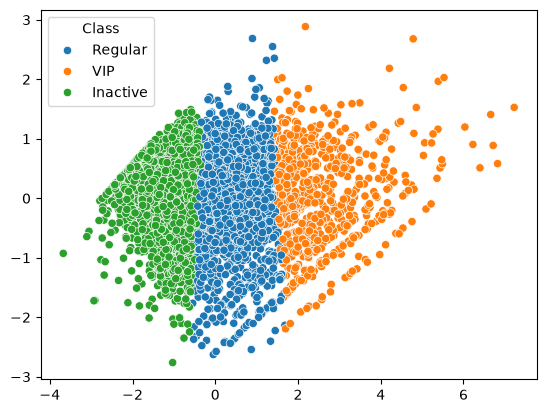

In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
cords = pca.fit_transform(rfm_standarized)
cords
pca.explained_variance_ratio_
pca.components_

sns.scatterplot(x=cords[:,0], y=cords[:,1], hue=rfm["Class"]) 



## Classification:

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = rfm[["Recency", "Frequency", "Monetary"]]
y = rfm["Cluster"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=77, stratify=y)

rf = RandomForestClassifier(n_estimators=100, random_state=77)
rf.fit(X_train, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",77
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

## Model Evaluation:

In [19]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


scores = cross_val_score(rf, X_train, y_train, cv=5, scoring="accuracy")
print(scores.mean(),scores.std())

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)

0.9829825633860215 0.003459274472701907
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       138
           1       0.99      0.99      0.99       393
           2       0.98      0.96      0.97       336

    accuracy                           0.98       867
   macro avg       0.97      0.98      0.98       867
weighted avg       0.98      0.98      0.98       867



array([[136,   0,   2],
       [  0, 390,   3],
       [  7,   5, 324]])

## Feature importance

In [26]:
values = rf.feature_importances_
columns = ["Recency", "Frequency", "Monetary"]
for c, v in zip(columns, values):
    print(f"{c} : {v.round(2) * 100 }%")

Recency : 30.0%
Frequency : 35.0%
Monetary : 35.0%


## predict a new customer:

In [ ]:
new_customer = pd.DataFrame({"Recency": [30], "Frequency": [5], "Monetary": [1500]})

cluster = int(rf.predict(new_customer)[0])
proba = rf.predict_proba(new_customer)[0]
print(cluster)
print(proba)

## save the model: